Missing club IDs:
 [      8       9      14 ... 4506868 4506869 4506870]


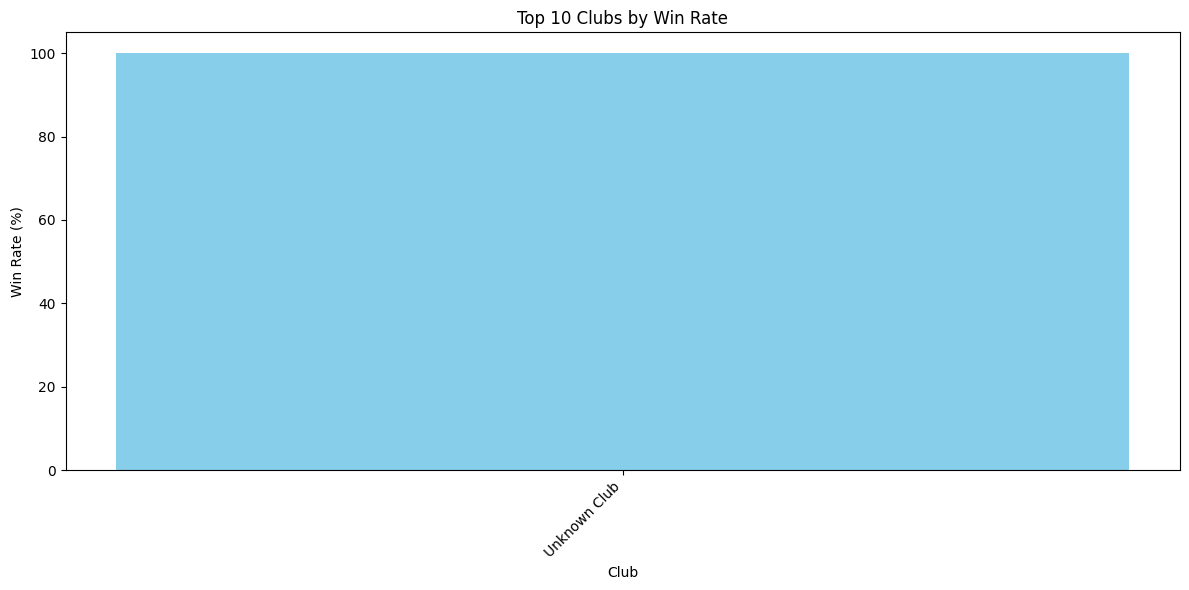

⚠️ Club IDs still missing from clubs_df: {32768, 8, 9, 14, 40977, 21, 22, 25, 26, 40979, 30, 49189, 16425, 48, 52, 56, 57, 61, 62, 63, 64, 66, 32832, 68, 69, 41029, 71, 72, 76, 77, 78, 81, 83, 84, 85, 73816, 90, 91, 92, 93, 94, 95, 96, 97, 41061, 16486, 103, 104, 16487, 107, 108, 109, 110, 111, 8303, 113, 115, 16492, 117, 65651, 119, 122, 129, 134, 8322, 82054, 82055, 82058, 24718, 144, 82062, 65682, 65683, 73876, 8343, 73877, 49306, 156, 158, 159, 82076, 163, 164, 8354, 49318, 168, 170, 171, 8364, 41127, 41133, 8373, 57527, 187, 16575, 16576, 195, 197, 24773, 199, 8397, 41166, 208, 209, 210, 16596, 215, 24791, 16602, 24794, 220, 222, 16611, 16612, 16613, 16614, 8424, 8428, 238, 239, 16619, 16622, 41197, 247, 8443, 253, 254, 255, 16640, 257, 8449, 24832, 260, 16646, 24839, 266, 16650, 41229, 271, 272, 41230, 275, 49430, 279, 282, 293, 299, 301, 16687, 16694, 312, 318, 321, 24898, 324, 327, 329, 330, 332, 337, 41300, 41303, 41304, 345, 41305, 349, 352, 353, 355, 16736, 358, 362, 24938, 

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

club_perf = club_perf.copy()
club_perf["club_id"] = club_perf["club_id"].astype(int)

clubs_df = pd.read_csv("D:/Projects/footytrackr/data/raw/clubs.csv")
clubs_df["club_id"] = clubs_df["club_id"].astype(int)

missing_ids = [1, 2, 7, 4506871, 4506872, 4506873]
patch_df = pd.DataFrame({
    "club_id": missing_ids,
    "name": [f"Club {i}" for i in missing_ids]
})
clubs_df = pd.concat([clubs_df, patch_df], ignore_index=True)

club_perf_named = club_perf.merge(
    clubs_df[["club_id", "name"]],
    on="club_id",
    how="left"
)

missing = club_perf_named[club_perf_named["name"].isna()]
if not missing.empty:
    print("Missing club IDs:\n", missing["club_id"].unique())

club_perf_named["name"] = club_perf_named["name"].fillna("Unknown Club")

top10 = club_perf_named.sort_values("win_rate", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10["name"], top10["win_rate"], color="skyblue")
plt.xlabel("Club")
plt.ylabel("Win Rate (%)")
plt.title("Top 10 Clubs by Win Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

all_ids_in_perf = club_perf["club_id"].unique()
known_ids = clubs_df["club_id"].unique()
still_missing = set(all_ids_in_perf) - set(known_ids)
if still_missing:
    print("⚠️ Club IDs still missing from clubs_df:", still_missing)


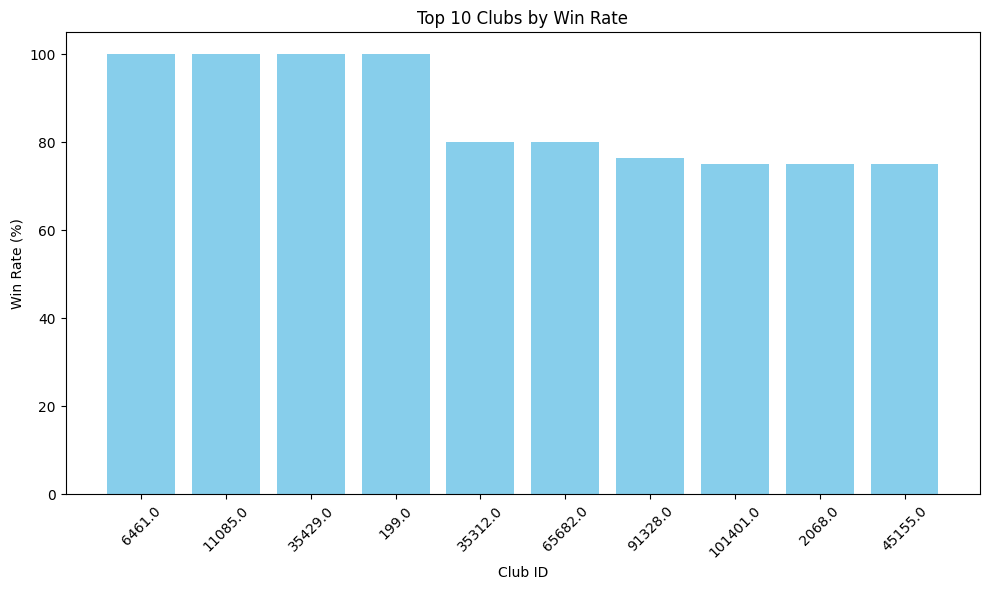

In [15]:
top10 = club_perf.sort_values("win_rate", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10["club_id"].astype(str), top10["win_rate"], color="skyblue")
plt.xlabel("Club ID")
plt.ylabel("Win Rate (%)")
plt.title("Top 10 Clubs by Win Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [16]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\mmash\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [17]:
# Group by club_id to calculate performance metrics
club_perf = df.groupby("club_id").agg(
    games_played=("game_id", "count"),
    goals_scored=("own_goals", "sum"),
    goals_conceded=("opponent_goals", "sum"),
    wins=("is_win", "sum")
).reset_index()

# Calculate win rate
club_perf["win_rate"] = club_perf["wins"] / club_perf["games_played"] * 100

# Show top of the result
club_perf.head()


,club_id,games_played,goals_scored,goals_conceded,wins,win_rate
0,1.0,16,37.0,39.0,10,62.500000
1,2.0,29,72.0,61.0,16,55.172414
2,3.0,354,498.0,567.0,109,30.790960
3,4.0,129,177.0,248.0,34,26.356589
4,5.0,623,1025.0,719.0,311,49.919743


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned club games data
df = pd.read_csv("D:/Projects/footytrackr/data/processed/club_games_clean.csv")
df.head()


,game_id,club_id,own_goals,own_position,own_manager_name,opponent_id,opponent_goals,opponent_position,opponent_manager_name,hosting,is_win
0,2320450,1468.0,0.0,NaN,Holger Bachthaler,24.0,2.0,NaN,Armin Veh,Home,0
1,2320454,222.0,0.0,NaN,Volkan Uluc,79.0,2.0,NaN,Bruno Labbadia,Home,0
2,2320460,1.0,3.0,NaN,Jürgen Luginger,86.0,1.0,NaN,Robin Dutt,Home,1
3,2320472,2036.0,4.0,NaN,Frank Schmidt,72.0,5.0,NaN,Alexander Schmidt,Home,0
4,2321027,33.0,3.0,8.0,Jens Keller,41.0,3.0,9.0,Thorsten Fink,Home,0
